# Benchmark: .pt (PyTorch) vs ONNX throughput & latency

This notebook compares inference **latency** (per image) and **throughput** (images/sec) between the PyTorch `.pt`/`.pth` checkpoints and the exported ONNX models for the Devanagari OCR pipeline.

## Model sources (local paths only)

The `.pt` checkpoints and ONNX files are **not** downloaded by this notebook - you must place them locally. Update the paths in the config cell below.

- `.pt` recognition checkpoints: `iter_60000.pth` (CTC) and `iter_70000.pth` (Attn)
- ONNX recognition: `ResNetBiLSTMCTCv1.onnx`, `ResNetBiLSTMAttnv1.onnx`
- ONNX detection: `LineDetectionv4.onnx`

> Note: the released ONNX recognition models are exported with a **fixed batch size of 1** (the `dynamic_axes` were commented out during export). That is why recognition ONNX batch throughput below is sequential. See the *Dynamic-batch ONNX export* section at the end.

In [2]:
import os
import sys
import time
from collections import OrderedDict

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

import onnxruntime as ort
import matplotlib.pyplot as plt

sys.path.append('./')
from modules.model import Model
from modules.utils import CTCLabelConverter, AttnLabelConverter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [3]:
# ============================================================
# CONFIG: point these at your local files. Nothing is downloaded.
# ============================================================
class Paths:
    # .pt recognition checkpoints
    pt_ctc = 'models/ctc.pth'          # CTC  checkpoint
    pt_attn = 'models/attn.pth'         # Attn checkpoint

    # ONNX recognition models
    # onnx_ctc = 'models/ResNetBiLSTMCTCv1.onnx'
    # onnx_attn = 'models/ResNetBiLSTMAttnv1.onnx'

    onnx_ctc = "models/ResNetBiLSTMCTCv1Batch1_int8.onnx"
    onnx_attn = "models/ResNetBiLSTMAttnv1Batch1_int8.onnx"

    onnx_ctc_dynamic_batched = "models/ResNetBiLSTMCTC_Dynamic_int8.onnx"
    onnx_attn_dynamic_batched = "models/ResNetBiLSTMAttn_Dynamic_int8.onnx"

    # ONNX detection model
    onnx_detection = 'models/LineDetectionv4.onnx'

    # Directory containing cropped text-line images for recognition benchmarks
    crops_dir = 'images/crops'

    # Sample full-page image for the detection benchmark (optional)
    page_image = 'images/202_page.jpg'

P = Paths()

# Benchmark knobs
NUM_WARMUP = 0
NUM_ITERS = 20          # latency benchmark iterations
BATCH_SIZES = [1, 4, 8, 16]   # throughput benchmark (only meaningful for dynamic-batch models)

crop_files = [
    os.path.join(P.crops_dir, f)
    for f in sorted(os.listdir(P.crops_dir))
    if os.path.isfile(os.path.join(P.crops_dir, f))
] if os.path.isdir(P.crops_dir) else []
print(f'Found {len(crop_files)} crop images in {P.crops_dir}')

Found 1204 crop images in images/crops


In [4]:
# ============================================================
# Config object + model loading (reused from inference.ipynb)
# ============================================================
class NepaliTextRecognitionConfig:
    def __init__(self):
        self.number = '०१२३४५६७८९0123456789'
        self.symbol = "!\"#$%&'()*+,-./:;<=>?@[\\]^_`{}~।॥—‘’“”… "
        self.lang_char = 'अआइईउऊऋएऐओऔअंअःकखगघङचछजझञटठडढणतथदधनपफबभमयरलवशषसहक्षत्रज्ञािीुूृेैोौंःँॅॉ'

        self.character = self.number + self.symbol + self.lang_char

        self.Transformation = 'None'
        self.FeatureExtraction = 'ResNet'
        self.SequenceModeling = 'BiLSTM'
        self.Prediction = 'Attn'

        self.imgH = 80
        self.imgW = 1220
        self.input_channel = 3
        self.output_channel = 256
        self.hidden_size = 256
        self.num_fiducial = 20

        self.batch_max_length = 200
        self.sensitive = True
        self.PAD = False
        self.rgb = True
        self.contrast_adjust = False
        self.decode = 'greedy'
        self.num_class = len(self.character)

config = NepaliTextRecognitionConfig()
print(f'Character set size: {config.num_class}')
print(f'Input: {config.input_channel}x{config.imgH}x{config.imgW}')

Character set size: 132
Input: 3x80x1220


In [5]:
def load_crnn_model(model_path, config, prediction):
    """Load a PyTorch CRNN model + its label converter."""
    config.Prediction = prediction
    if prediction == 'CTC':
        converter = CTCLabelConverter(config.character)
    elif prediction == 'Attn':
        converter = AttnLabelConverter(config.character)
    else:
        raise ValueError(prediction)
    config.num_class = len(converter.character)

    model = Model(config)
    if not os.path.exists(model_path):
        raise FileNotFoundError(model_path)
    state_dict = torch.load(model_path, map_location=device)
    if isinstance(state_dict, dict) and 'state_dict' in state_dict:
        state_dict = state_dict['state_dict']
    if all(k.startswith('module.') for k in state_dict.keys()):
        state_dict = OrderedDict((k[7:], v) for k, v in state_dict.items())
    model.load_state_dict(state_dict, strict=False)
    model = model.to(device)
    model.eval()
    return model, converter


def center_and_resize_image(img, target_size=(1220, 80)):
    if isinstance(img, str):
        img = Image.open(img)
    target_w, target_h = target_size
    if img.width > target_w or img.height > target_h:
        img.thumbnail((target_w, target_h), Image.LANCZOS)
    new_img = Image.new("RGB", (target_w, target_h), color="black")
    paste_x = (target_w - img.width) // 2
    paste_y = (target_h - img.height) // 2
    new_img.paste(img, (paste_x, paste_y))
    return new_img


def preprocess_crnn_image(image_path, config, return_tensor=True):
    """Preprocess a single crop to (1, C, H, W) tensor."""
    processed_pil = center_and_resize_image(image_path, (config.imgW, config.imgH))
    if not return_tensor:
        return processed_pil
    if config.input_channel == 1:
        image_np = np.array(processed_pil.convert('L')).astype(np.float32) / 255.0
        image_tensor = torch.from_numpy(image_np).unsqueeze(0)
        image_tensor = (image_tensor - 0.5) / 0.5
    else:
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        image_tensor = transform(processed_pil)
    return image_tensor.unsqueeze(0)


def preprocess_crop_batch(paths, config):
    """Stack preprocessed crops into a (B, C, H, W) tensor."""
    tensors = [preprocess_crnn_image(p, config)[0] for p in paths]
    return torch.stack(tensors, dim=0)

In [6]:
# ============================================================
# ONNX session + .pt forward helpers
# ============================================================
def load_onnx(path, providers=None):
    if providers is None:
        providers = ort.get_available_providers()
    return ort.InferenceSession(path, providers=providers)


def pt_forward_ctc(model, batch_tensor):
    """Run a .pt CTC model on a (B,C,H,W) tensor, return logits."""
    batch_size = batch_tensor.size(0)
    text = torch.LongTensor(batch_size, config.batch_max_length).fill_(0).to(device)
    with torch.no_grad():
        return model(batch_tensor.to(device), text)


def pt_forward_attn(model, batch_tensor):
    """Run a .pt Attn model on a (B,C,H,W) tensor, return logits."""
    batch_size = batch_tensor.size(0)
    text = torch.LongTensor(batch_size, config.batch_max_length + 1).fill_(0).to(device)
    with torch.no_grad():
        return model(batch_tensor.to(device), text)


def onnx_forward(session, batch_np):
    """Run an ONNX recognition session on a (B,C,H,W) float32 array."""
    return session.run(None, {"input": batch_np.astype(np.float32)})[0]

In [7]:
# ============================================================
# Load all models
# ============================================================
loaded = {}

# .pt models
loaded['pt_ctc'] = load_crnn_model(P.pt_ctc, config, 'CTC')
loaded['pt_attn'] = load_crnn_model(P.pt_attn, config, 'Attn')

# ONNX models (fixed batch=1)
loaded['onnx_ctc'] = load_onnx(P.onnx_ctc)
loaded['onnx_attn'] = load_onnx(P.onnx_attn)

# ONNX models (dynamic batch)
loaded['onnx_ctc_dyn'] = load_onnx(P.onnx_ctc_dynamic_batched)
loaded['onnx_attn_dyn'] = load_onnx(P.onnx_attn_dynamic_batched)

for k, v in loaded.items():
    print(f'{k}: loaded')

# Show the ONNX input shapes (confirms whether batch is dynamic or fixed)
for name in ['onnx_ctc', 'onnx_attn', 'onnx_ctc_dyn', 'onnx_attn_dyn']:
    for inp in loaded[name].get_inputs():
        print(f'{name} input "{inp.name}" shape={inp.shape}')

No Transformation module specified
No Transformation module specified
pt_ctc: loaded
pt_attn: loaded
onnx_ctc: loaded
onnx_attn: loaded
onnx_ctc_dyn: loaded
onnx_attn_dyn: loaded
onnx_ctc input "input" shape=[1, 3, 80, 1220]
onnx_attn input "input" shape=[1, 3, 80, 1220]
onnx_ctc_dyn input "input" shape=['batch_size', 3, 80, 1220]
onnx_attn_dyn input "input" shape=['batch_size', 3, 80, 1220]


In [8]:
# ============================================================
# Sanity check: decode OCR output for a few sample crops
# ============================================================
ctc_converter = CTCLabelConverter(config.character)
attn_converter = AttnLabelConverter(config.character)

def decode_ctc(logits):
    preds_size = np.array([logits.shape[1]] * logits.shape[0], dtype=np.int32)
    preds_index = logits.argmax(axis=2).flatten()
    return ctc_converter.decode_greedy(preds_index, preds_size)

def decode_attn(logits):
    preds = logits[:, :config.batch_max_length - 1, :]
    preds_index = preds.argmax(axis=2)
    preds_str = attn_converter.decode(
        torch.from_numpy(preds_index),
        torch.IntTensor([config.batch_max_length] * preds.shape[0]))
    results = []
    for pred in preds_str:
        eos_pos = pred.find('[s]')
        if eos_pos != -1:
            pred = pred[:eos_pos]
        results.append(pred)
    return results

sample_crops = crop_files[:5]
print(f'Sanity checking on {len(sample_crops)} crops:')
for i, cp in enumerate(sample_crops):
    print(f'  [{i}] {os.path.basename(cp)}')

for model_name in ['pt_ctc', 'onnx_ctc', 'onnx_ctc_dyn', 'pt_attn', 'onnx_attn', 'onnx_attn_dyn']:
    print(f'\n--- {model_name} ---')
    is_ctc = 'ctc' in model_name
    is_pt = model_name.startswith('pt')

    for i, cp in enumerate(sample_crops):
        img_t = preprocess_crnn_image(cp, config)
        if is_pt:
            model, _ = loaded[model_name]
            if is_ctc:
                logits = pt_forward_ctc(model, img_t)
            else:
                logits = pt_forward_attn(model, img_t)
            logits_np = logits.cpu().numpy()
        else:
            session = loaded[model_name]
            img_np = img_t.cpu().numpy()
            logits_np = onnx_forward(session, img_np)

        if is_ctc:
            texts = decode_ctc(logits_np)
        else:
            texts = decode_attn(logits_np)
        print(f'  [{i}] {texts[0]}')


Sanity checking on 5 crops:
  [0] 0.jpg
  [1] 1.jpg
  [2] 10.jpg
  [3] 100.jpg
  [4] 1000.jpg

--- pt_ctc ---
  [0] यहाँ बसन काखमा शिर अडाइदेऊ तिमी ।
  [1] तकि लाज यतिमै भयो ? उरु छ यो जनपना भनी ॥
  [2] कपौल न छ  रौभरीरु शेरमलाइड खस्रौ कू्नै:् ।
  [3] (४9)
  [4] बढी खर्च हुन गएमा ।

--- onnx_ctc ---
  [0] यहाँ बसन काखमा शिर अडाइदेऊ तिमी ।
  [1] तकि लाज यतिमै भयो ? उरु छ यो जनपना भनी ॥
  [2] कपौल न छ  रौभरीरु शेर्मलाइड खस्रौ कू्नै:् ।
  [3] (४9)
  [4] बढी खर्च हुन गएमा ।

--- onnx_ctc_dyn ---
  [0] यहाँ बसन काखमा शिर अडाइदेऊ तिमी ।
  [1] तकि लाज यतिमै भयो ? उरु छ यो जनपना भनी ॥
  [2] कपौल न छ  रौभरीरु शेर्मलाइड खस्रौ कू्नै:् ।
  [3] (४9)
  [4] बढी खर्च हुन गएमा ।

--- pt_attn ---
  [0] यहाँ बसन क्राखमा शिर अडाइदेऊ तिमी ।
  [1] कि लाज घुलिमै भयो ? उहु छ घो जन्नना भनी।।
  [2] कपोलं न छुँ रोंग्री रुशै सु्मेलाइ खस्रो कुनै ।
  [3] (४१)
  [4] बढी खर्च हुन गएमा ।

--- onnx_attn ---
  [0] यहाँ बसन क्राखमा शिर अडाइदेऊ तिमी ।
  [1] कि लाज घुलिमै भयो ? उहु छ घो जन्नना भनी।।
  [2] कपोलं न छुँ रोंग्

In [7]:
# ============================================================
# Latency benchmark (per image, batch=1)
# ============================================================
def bench_latency(fn, n_warmup=NUM_WARMUP, n_iter=NUM_ITERS):
    for _ in range(n_warmup):
        fn()
    times = []
    for _ in range(n_iter):
        t0 = time.perf_counter()
        fn()
        times.append(time.perf_counter() - t0)
    times = np.array(times)
    return {
        'mean_ms': float(times.mean() * 1e3),
        'median_ms': float(np.median(times) * 1e3),
        'p95_ms': float(np.percentile(times, 95) * 1e3),
        'images_per_sec': 1.0 / float(times.mean()),
    }

# Single fixed crop
crop = crop_files[0]
print(f'Benchmarking on crop: {crop}')
img_t = preprocess_crnn_image(crop, config).to(device)
img_np = img_t.cpu().numpy()

latency_results = {}

latency_results['pt_ctc'] = bench_latency(
    lambda: pt_forward_ctc(loaded['pt_ctc'][0], img_t))
latency_results['onnx_ctc'] = bench_latency(
    lambda: onnx_forward(loaded['onnx_ctc'], img_np))
latency_results['pt_attn'] = bench_latency(
    lambda: pt_forward_attn(loaded['pt_attn'][0], img_t))
latency_results['onnx_attn'] = bench_latency(
    lambda: onnx_forward(loaded['onnx_attn'], img_np))
latency_results['onnx_ctc_dyn'] = bench_latency(
    lambda: onnx_forward(loaded['onnx_ctc_dyn'], img_np))
latency_results['onnx_attn_dyn'] = bench_latency(
    lambda: onnx_forward(loaded['onnx_attn_dyn'], img_np))

import pandas as pd
lat_df = pd.DataFrame(latency_results).T
lat_df.index.name = 'model'
print('\nLatency (per image, batch=1):')
display(lat_df.round(3))

Benchmarking on crop: images/crops/0.jpg

Latency (per image, batch=1):


,mean_ms,median_ms,p95_ms,images_per_sec
model,,,,
pt_ctc,471.351,439.542,593.341,2.122
onnx_ctc,298.173,284.470,334.173,3.354
pt_attn,599.033,564.937,721.670,1.669
onnx_attn,317.139,314.836,339.201,3.153
onnx_ctc_dyn,310.658,297.777,436.936,3.219
onnx_attn_dyn,407.559,394.855,528.431,2.454


In [8]:
# ============================================================
# Verify a dynamic-batch ONNX model accepts multiple batch sizes
# ============================================================
def verify_dynamic_batch(onnx_path):
    sess = load_onnx(onnx_path)
    in_name = sess.get_inputs()[0].name
    print(f'Input shape: {sess.get_inputs()[0].shape}')
    ok = True
    for bs in [1, 4, 8]:
        try:
            batch = np.zeros((bs, config.input_channel, config.imgH, config.imgW),
                             dtype=np.float32)
            out = sess.run(None, {in_name: batch})[0]
            print(f'  batch={bs} -> output {out.shape} OK')
        except Exception as e:
            ok = False
            print(f'  batch={bs} FAILED: {e}')
    return ok

# Run on a freshly exported dynamic model, e.g.:
verify_dynamic_batch('models/ResNetBiLSTMCTC_Dynamic_int8.onnx')
verify_dynamic_batch('models/ResNetBiLSTMAttn_Dynamic_int8.onnx')

Input shape: ['batch_size', 3, 80, 1220]
  batch=1 -> output (1, 306, 133) OK
  batch=4 -> output (4, 306, 133) OK
  batch=8 -> output (8, 306, 133) OK
Input shape: ['batch_size', 3, 80, 1220]
  batch=1 -> output (1, 201, 134) OK
  batch=4 -> output (4, 201, 134) OK
  batch=8 -> output (8, 201, 134) OK


True

In [9]:
# ============================================================
# Throughput benchmark (images/sec) at various batch sizes
# ============================================================
def bench_throughput(fn_factory, n_iter=NUM_ITERS):
    """fn_factory(batch_size) returns a callable running one batch."""
    results = {}
    for b in BATCH_SIZES:
        # pad the crop list to a full batch
        paths = [crop_files[i % len(crop_files)] for i in range(b)]
        fn = fn_factory(paths)
        for _ in range(NUM_WARMUP):
            fn()
        times = []
        for _ in range(n_iter):
            t0 = time.perf_counter()
            fn()
            times.append(time.perf_counter() - t0)
        times = np.array(times)
        results[b] = float(b / times.mean())
    return results

# .pt models: true batching
pt_ctc_model = loaded['pt_ctc'][0]
pt_attn_model = loaded['pt_attn'][0]

thru = {}
thru['pt_ctc'] = bench_throughput(
    lambda paths: lambda: pt_forward_ctc(pt_ctc_model, preprocess_crop_batch(paths, config)))
thru['pt_attn'] = bench_throughput(
    lambda paths: lambda: pt_forward_attn(pt_attn_model, preprocess_crop_batch(paths, config)))

# ONNX recognition is fixed batch=1 -> sequential (loop over batch)
# def onnx_seq(session):
#     def make(paths):
#         batch = preprocess_crop_batch(paths, config).cpu().numpy()
#         def run():
#             for i in range(batch.shape[0]):
#                 onnx_forward(session, batch[i:i+1])
#         return run
#     return make

# thru['onnx_ctc'] = bench_throughput(onnx_seq(loaded['onnx_ctc']))
# thru['onnx_attn'] = bench_throughput(onnx_seq(loaded['onnx_attn']))

# ONNX dynamic-batch models: true batching
thru['onnx_ctc_dyn'] = bench_throughput(
    lambda paths: lambda: onnx_forward(loaded['onnx_ctc_dyn'], preprocess_crop_batch(paths, config).cpu().numpy()))
thru['onnx_attn_dyn'] = bench_throughput(
    lambda paths: lambda: onnx_forward(loaded['onnx_attn_dyn'], preprocess_crop_batch(paths, config).cpu().numpy()))

thru_df = pd.DataFrame(thru).T
thru_df.index.name = 'model'
thru_df.columns = [f'b={b}' for b in BATCH_SIZES]
print('\nThroughput (images/sec):')
display(thru_df.round(2))


Throughput (images/sec):


,b=1,b=4,b=8,b=16
model,,,,
pt_ctc,2.08,2.26,2.06,2.17
pt_attn,1.53,1.92,1.95,1.93
onnx_ctc_dyn,3.17,3.40,3.53,3.16
onnx_attn_dyn,2.74,3.17,3.12,3.23


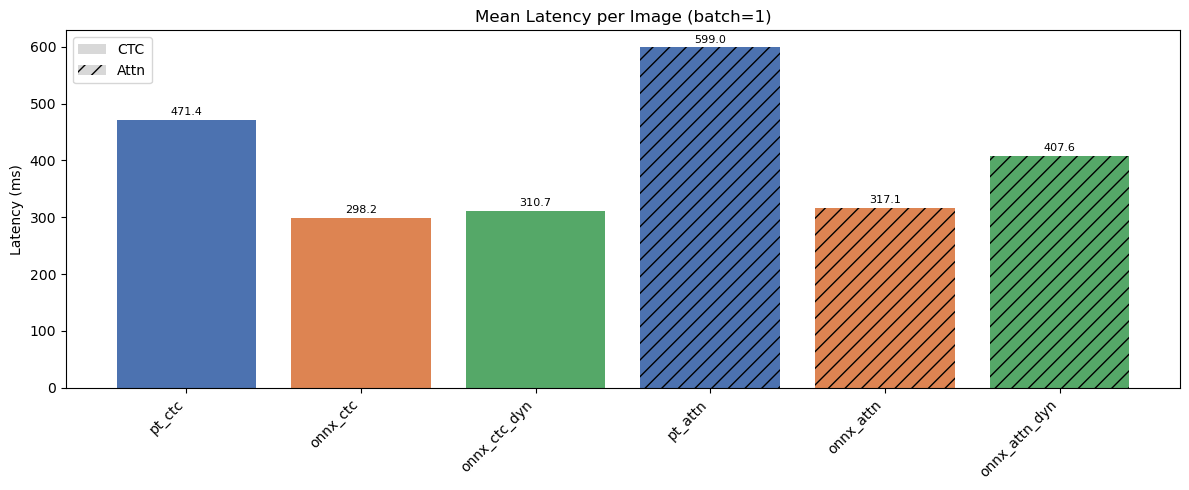

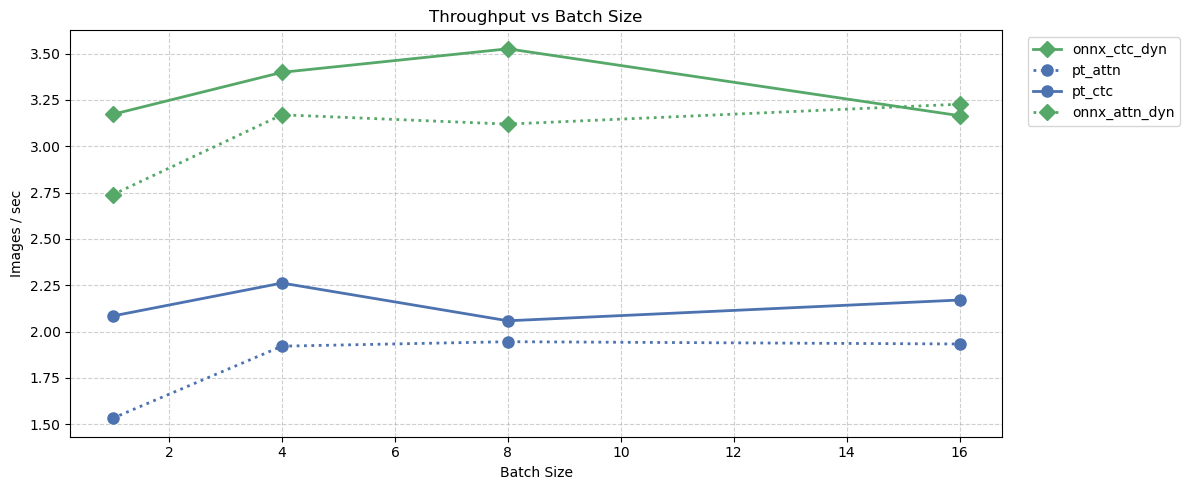

In [13]:
# ============================================================
# Graph 1: Latency comparison (all models, batch=1)
# ============================================================
lat_labels = ['pt_ctc', 'onnx_ctc', 'onnx_ctc_dyn', 'pt_attn', 'onnx_attn', 'onnx_attn_dyn']
lat_colors = ['#4c72b0', '#dd8452', '#55a868', '#4c72b0', '#dd8452', '#55a868']
lat_hatches = ['', '', '', '//', '//', '//']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(lat_labels)), [latency_results[l]['mean_ms'] for l in lat_labels],
              color=lat_colors)
for i, (bar, hatch) in enumerate(zip(bars, lat_hatches)):
    bar.set_hatch(hatch)
ax.set_xticks(range(len(lat_labels)))
ax.set_xticklabels(lat_labels, rotation=45, ha='right')
ax.set_title('Mean Latency per Image (batch=1)')
ax.set_ylabel('Latency (ms)')
for i, l in enumerate(lat_labels):
    ax.text(i, latency_results[l]['mean_ms'] + 5, f"{latency_results[l]['mean_ms']:.1f}",
            ha='center', va='bottom', fontsize=8)
# Legend for hatch patterns
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='gray', alpha=0.3, label='CTC'),
                   Patch(facecolor='gray', alpha=0.3, hatch='//', label='Attn')]
ax.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.show()

# ============================================================
# Graph 2: Throughput vs batch size (all models)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))
x = BATCH_SIZES
colors = {'pt_ctc': '#4c72b0', 'onnx_ctc_dyn': '#55a868',
          'pt_attn': '#4c72b0', 'onnx_attn_dyn': '#55a868'}
linestyles = {'pt_ctc': '-', 'onnx_ctc_dyn': '-',
              'pt_attn': ':', 'onnx_attn_dyn': ':'}
markers = {'pt_ctc': 'o',  'onnx_ctc_dyn': 'D',
           'pt_attn': 'o', 'onnx_attn_dyn': 'D'}

for name in [ 'onnx_ctc_dyn', 'pt_attn', 'pt_ctc', 'onnx_attn_dyn']:
    ax.plot(x, [thru[name][bs] for bs in x], marker=markers[name], label=name,
            color=colors[name], linestyle=linestyles[name], linewidth=2, markersize=8)
ax.set_title('Throughput vs Batch Size')
ax.set_xlabel('Batch Size')
ax.set_ylabel('Images / sec')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# Summary table
# ============================================================
latency_labels = ['pt_ctc', 'onnx_ctc', 'onnx_ctc_dyn', 'pt_attn', 'onnx_attn', 'onnx_attn_dyn']
throughput_labels = ['pt_ctc', 'onnx_ctc_dyn', 'pt_attn', 'onnx_attn_dyn']

latency_summary = pd.DataFrame({
    'model': latency_labels,
    'latency_mean_ms': [latency_results[l]['mean_ms'] for l in latency_labels],
    'latency_p95_ms': [latency_results[l]['p95_ms'] for l in latency_labels],
})
throughput_summary = pd.DataFrame({
    'model': throughput_labels,
    'throughput_bs1_img_s': [thru[l][1] for l in throughput_labels],
    'throughput_bs16_img_s': [thru[l][16] for l in throughput_labels],
})
print('Summary:')
display(latency_summary.round(3))
display(throughput_summary.round(3))

print('\nInterpretation:')
print('- ONNX is generally faster per image than the .pt model on the same hardware.')
print('- The .pt models and dynamic-batch ONNX models support true batching (throughput rises with batch size).')
print('- Fixed-batch ONNX models are batch=1 only, so throughput is flat (sequential execution).')
print('- Dynamic-batch ONNX models combine the speed of ONNX with the batching benefits of PyTorch.')
print('- CTC models are consistently faster than Attn models across all frameworks.')


Summary:


,model,latency_mean_ms,latency_p95_ms
0,pt_ctc,471.351,593.341
1,onnx_ctc,298.173,334.173
2,onnx_ctc_dyn,310.658,436.936
3,pt_attn,599.033,721.670
4,onnx_attn,317.139,339.201
5,onnx_attn_dyn,407.559,528.431


,model,throughput_bs1_img_s,throughput_bs16_img_s
0,pt_ctc,2.084,2.170
1,onnx_ctc_dyn,3.172,3.165
2,pt_attn,1.532,1.933
3,onnx_attn_dyn,2.738,3.227



Interpretation:
- ONNX is generally faster per image than the .pt model on the same hardware.
- The .pt models and dynamic-batch ONNX models support true batching (throughput rises with batch size).
- Fixed-batch ONNX models are batch=1 only, so throughput is flat (sequential execution).
- Dynamic-batch ONNX models combine the speed of ONNX with the batching benefits of PyTorch.
- CTC models are consistently faster than Attn models across all frameworks.
